<a href="https://colab.research.google.com/github/driri85/Data-IA-Projet/blob/main/Data_IA_Projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Question prédictive**

Quelle genre de JV sera le plus vendu en 2017 ?

In [ ]:
import pandas as pd

df = pd.read_csv("data.csv")
print(df.head())

                       Name Platform  Year_of_Release         Genre Publisher  \
0                Wii Sports      Wii           2006.0        Sports  Nintendo   
1         Super Mario Bros.      NES           1985.0      Platform  Nintendo   
2            Mario Kart Wii      Wii           2008.0        Racing  Nintendo   
3         Wii Sports Resort      Wii           2009.0        Sports  Nintendo   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  Critic_Score  \
0     41.36     28.96      3.77         8.45         82.53          76.0   
1     29.08      3.58      6.81         0.77         40.24           NaN   
2     15.68     12.76      3.79         3.29         35.52          82.0   
3     15.61     10.93      3.28         2.95         32.77          80.0   
4     11.27      8.89     10.22         1.00         31.37           NaN   

   Critic_Count User_Score  User_Count Developer Rating 

Descriptive Statistics for Sales and Scores:
       Global_Sales  Critic_Score  Year_of_Release
count  16719.000000   8137.000000     16450.000000
mean       0.533543     68.967679      2006.487356
std        1.547935     13.938165         5.878995
min        0.010000     13.000000      1980.000000
25%        0.060000     60.000000      2003.000000
50%        0.170000     71.000000      2007.000000
75%        0.470000     79.000000      2010.000000
max       82.530000     98.000000      2020.000000


Correlation Matrix for Sales and Scores:
              Global_Sales  NA_Sales  EU_Sales  JP_Sales  Other_Sales  \
Global_Sales      1.000000  0.941010  0.901239  0.612300     0.749242   
NA_Sales          0.941010  1.000000  0.765336  0.449598     0.638654   
EU_Sales          0.901239  0.765336  1.000000  0.435068     0.722796   
JP_Sales          0.612300  0.449598  0.435068  1.000000     0.291096   
Other_Sales       0.749242  0.638654  0.722796  0.291096     1.000000   
Critic_Score   

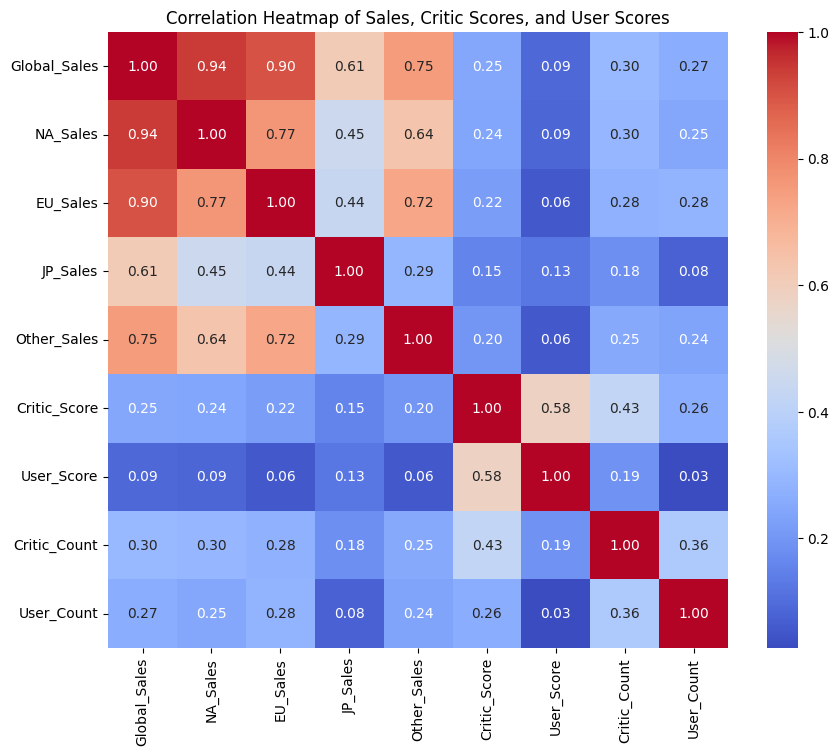

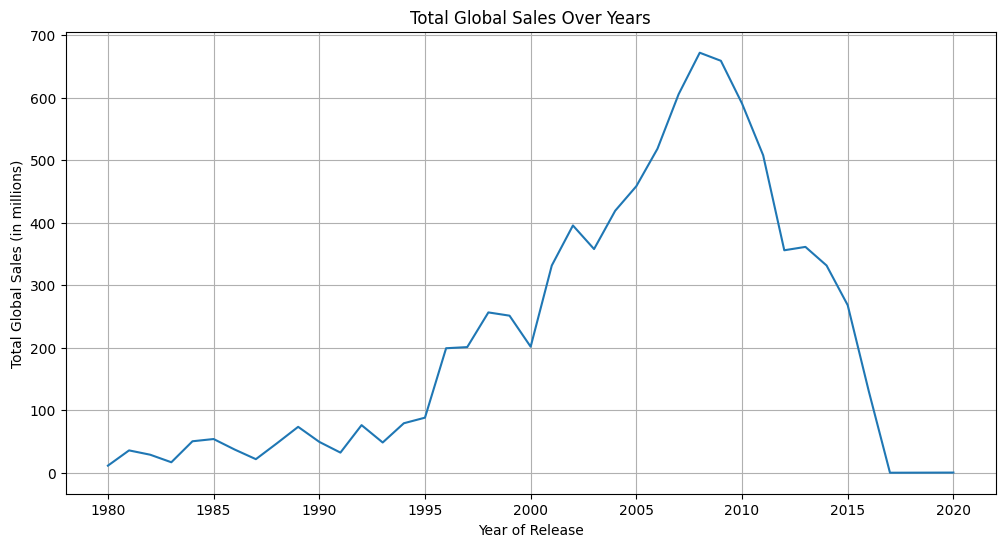

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display descriptive statistics for key numerical columns
print("Descriptive Statistics for Sales and Scores:")
print(df[['Global_Sales', 'Critic_Score', 'User_Score', 'Year_of_Release']].describe())
print("\n")

# Focus on correlations of interest
# Convert 'User_Score' to numeric, coercing errors to NaN
df['User_Score'] = pd.to_numeric(df['User_Score'], errors='coerce')

# Create a subset for correlation analysis with relevant columns
correlation_subset = df[['Global_Sales', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Critic_Score', 'User_Score', 'Critic_Count', 'User_Count']]

print("Correlation Matrix for Sales and Scores:")
correlation_matrix = correlation_subset.corr()
print(correlation_matrix)
print("\n")

# Heatmap for the focused correlation matrix
print("Generating Correlation Heatmap for Sales and Scores...")
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Sales, Critic Scores, and User Scores')
plt.show()

# Global Sales over Year of Release
plt.figure(figsize=(12, 6))
sales_by_year = df.groupby('Year_of_Release')['Global_Sales'].sum().reset_index()
sns.lineplot(x='Year_of_Release', y='Global_Sales', data=sales_by_year)
plt.title('Total Global Sales Over Years')
plt.xlabel('Year of Release')
plt.ylabel('Total Global Sales (in millions)')
plt.grid(True)
plt.show()

### Étape 03 : Définition de X et y

Après avoir exploré les corrélations et les statistiques descriptives, nous devons isoler notre cible (`Global_Sales`) des caractéristiques (features) qui serviront à la prédiction. Nous supprimons les colonnes de ventes régionales pour éviter les fuites de données (data leakage).

In [ ]:
# Sélection des colonnes pertinentes et gestion des valeurs manquantes simples pour l'exemple
features = ['Platform', 'Genre', 'Critic_Score', 'User_Score', 'Rating']
target = 'Global_Sales'

# Suppression des lignes avec des cibles manquantes
data_model = df.dropna(subset=[target])

X = data_model[features]
y = data_model[target]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (16719, 5)
y shape: (16719,)


### Étape 04 : Split train/val/test

Maintenant que nos variables sont définies, nous divisons notre dataset en trois ensembles : un pour l'entraînement, un pour la validation (ajustement des hyperparamètres) et un pour le test final.

In [ ]:
from sklearn.model_selection import train_test_split

# Split initial : Train + Val vs Test
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Second split : Train vs Val
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

Train size: 10031, Val size: 3344, Test size: 3344


### Étape 05 : ColumnTransformer

Les données contiennent des variables textuelles (catégorielles) et numériques. Nous créons un transformateur pour appliquer un `OneHotEncoder` sur les catégories et un `StandardScaler` sur les nombres.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_features = ['Critic_Score', 'User_Score']
categorical_features = ['Platform', 'Genre', 'Rating']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

### Étape 06 : Pipeline complet

Nous assemblons le préprocesseur et l'algorithme de Regression Linéaire dans un seul objet `Pipeline` pour simplifier le traitement et éviter les erreurs de transformation.

In [ ]:
from sklearn.linear_model import LinearRegression

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

### Étape 07 : Fit + Score

Nous entraînons le modèle sur les données d'entraînement et évaluons sa performance sur l'ensemble de validation en utilisant le coefficient de détermination R².

In [ ]:
model_pipeline.fit(X_train, y_train)

val_score = model_pipeline.score(X_val, y_val)
print(f"R² score on validation set: {val_score:.4f}")

R² score on validation set: 0.1208


### Étape 08 : Visualisation

Enfin, nous visualisons la qualité des prédictions en comparant les valeurs réelles aux valeurs prédites par le modèle.

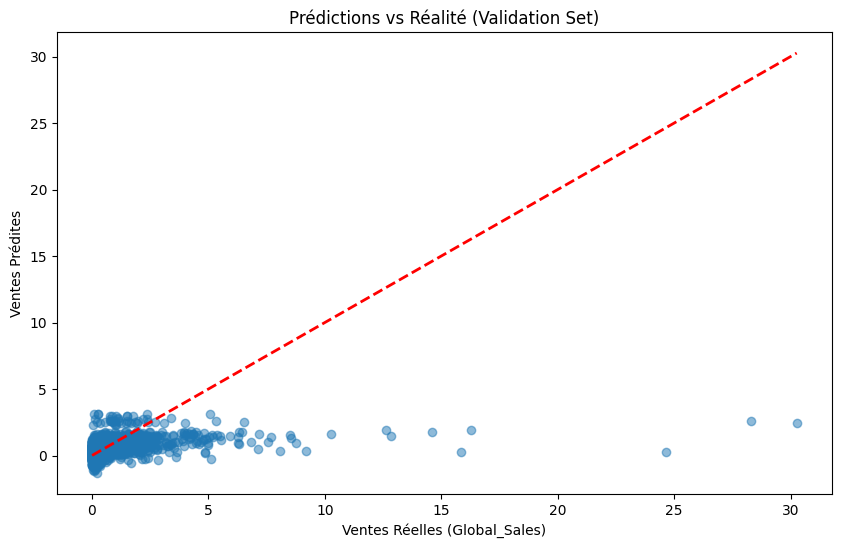

In [ ]:
y_pred = model_pipeline.predict(X_val)

plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel('Ventes Réelles (Global_Sales)')
plt.ylabel('Ventes Prédites')
plt.title('Prédictions vs Réalité (Validation Set)')
plt.show()